# Notebook 01e: Correlation Analysis

## README

### What this notebook does
Loads the **monthly tile panel** produced by `01d` for each city
(`data/processed/{city}/grid_panel/{city}_monthly_tile_panel.csv`) and analyses
linear (Pearson) and monotonic (Spearman) correlations between all numeric
features, with a specific focus on:

1. **NO₂ vs TCI** — the headline relationship of interest (does traffic-related
   air pollution track congestion?).
2. **All features vs TCI** — ranking every available predictor by its
   correlation strength with the target, per city and pooled across cities.
3. **Feature × feature** — a full correlation matrix to flag multicollinearity
   before it reaches the modelling notebooks (`02+`).

### Why this matters for the project
The World Bank client requires **interpretability**. Before any LightGBM /
OLS / Lasso model is fit, we want a transparent, model-free view of which
features move with TCI and which features are redundant with each other.
This also surfaces city-specific differences in the NO₂–TCI relationship,
which is directly relevant to the **cross-city generalization** goal: if the
sign or strength of the NO₂–TCI relationship is inconsistent across cities,
that's an early warning that a single pooled model may not transfer well.

### Column discovery (no hardcoded feature list)
This notebook does **not** assume a fixed set of feature columns. It
auto-detects all numeric columns in each city's monthly panel and excludes
known **identifier / diagnostic** columns (e.g. `year`, `month`, coverage %
and `n_days_*` counters, centroid coordinates). This makes the notebook
robust to however many raw features (`no2`, `era5_temp`, NTL, building
height, O₃, etc.) ended up in the panel for a given run — whatever is
present in the CSV is what gets correlated, nothing more, nothing less.
If you want to force-exclude or force-include specific columns, edit
`EXTRA_EXCLUDE_COLS` / `FORCE_INCLUDE_COLS` in the **USER INPUTS** cell below.

### Two levels of analysis
| Level | What it shows | Use case |
|---|---|---|
| **Per-city** | Correlation matrix + TCI ranking computed within each city's own tile-months | Detect city-specific relationships; sanity-check before pooling |
| **Pooled (all cities stacked)** | Same, but on the concatenated panel across all cities loaded | Headline numbers for the report; the "average" relationship the model will see if trained on multiple cities |

### Outputs (per city + pooled)
- `data/processed/{city}/grid_panel/{city}_correlation_matrix_pearson.csv`
- `data/processed/{city}/grid_panel/{city}_correlation_matrix_spearman.csv`
- `data/processed/{city}/grid_panel/{city}_tci_correlations.csv`
- `data/processed/{city}/grid_panel/{city}_correlation_heatmap.png`
- `outputs/correlation_analysis/pooled_correlation_matrix_pearson.csv`
- `outputs/correlation_analysis/pooled_correlation_matrix_spearman.csv`
- `outputs/correlation_analysis/pooled_tci_correlations.csv`
- `outputs/correlation_analysis/tci_correlation_by_city.png`
- `outputs/correlation_analysis/pooled_correlation_heatmap.png`


### Going further: from "is there a correlation" to "where, and is it real"
Sections 1–9 above answer "is NO₂ correlated with TCI" using a **pooled**
correlation — every tile-month treated as one point in a single scatter
cloud. That conflates cross-sectional differences between tiles (some tiles
are just busier than others, in both NO₂ and TCI, as a fixed trait) with
genuine month-to-month co-movement. Sections 11–12 unpack this:

- **Section 11** decomposes the pooled correlation into its **between-tile**
  (cross-sectional) and **within-tile** (temporal, demeaned) components, so
  you can see how much of the pooled number is "busy tiles are busy" versus
  real temporal tracking.
- **Section 12** computes a **separate correlation per tile** (NO₂ vs TCI,
  across that tile's own months) and renders it as a **choropleth map** on
  the city grid — directly answering "where in the city does NO₂ track
  congestion most strongly?" Tiles with too few valid months are shown in
  grey rather than guessed at.

### Additional outputs (Sections 11–12)
- `outputs/correlation_analysis/tci_correlation_decomposition.csv` / `.png`
- `data/processed/{city}/grid_panel/{city}_tile_no2_tci_correlation.csv`
- `data/processed/{city}/grid_panel/{city}_tile_no2_tci_correlation_map.png`
- `data/processed/{city}/grid_panel/{city}_tile_no2_tci_correlation_hist.png`
- `outputs/correlation_analysis/tile_no2_tci_correlation_summary_by_city.csv`

### Dependency note
Section 12's map requires `geopandas` and each city's
`{city}_grid_geometry.gpkg` (produced by `01b`). If either is unavailable,
that section prints a clear message and skips itself — the per-tile
correlation CSV is still produced and saved, so you can map it separately
(e.g. in QGIS) by joining on `spatial_id`.


## 0. Setup

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

def find_project_root(start: Path, marker: str = 'src') -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find '{marker}/' above {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

try:
    import geopandas as gpd
    GEOPANDAS_AVAILABLE = True
except ImportError:
    GEOPANDAS_AVAILABLE = False
    print('⚠ geopandas not installed — Section 12 (grid maps) will be skipped. '
          'Install with: pip install geopandas')

print('✓ Libraries loaded')


✓ Libraries loaded


## 1. USER INPUTS

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# USER INPUTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

DATA_ROOT   = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'correlation_analysis'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# All 17 World Bank cities in scope for this project. Cities whose monthly
# panel CSV is not found are skipped automatically (see pre-flight check) —
# you do not need to comment cities out, but you can restrict the list here
# for a quick local run (e.g. FAST_DEV_MODE-style subsetting).
CITIES = [
    'abuja',
    'algiers',
    'baghdad',
    'buenos_aires',
    'cairo',
    'cape_town',
    'cebu',
    'dakar',
    'lima',
    'los_angeles',
    'madrid',
    'mexico_city',
    'mumbai',
    'nairobi',
    'new_york',
    'santiago',
    'yangon',
]

# Identifier / metadata columns — never treated as numeric features even if
# they happen to be numeric dtype (e.g. 'year', 'month', 'spatial_id').
ID_COLS = {'city', 'spatial_id', 'year', 'month', 'date'}

# Diagnostic / coverage columns produced by 01d — these describe *how much*
# data went into a monthly average, not a physical feature, so they are
# excluded from the correlation analysis by default.
DIAGNOSTIC_COLS = {
    'n_days_no2', 'n_days_temp', 'n_days_tci', 'n_days_total',
    'cov_no2_pct', 'cov_temp_pct', 'cov_tci_pct',
}

# Coordinates are spatial references, not predictive features in the
# correlation sense — excluded by default (set to set() to include them).
COORD_COLS = {'centroid_lon', 'centroid_lat'}

# Target column.
TCI_COL = 'tci'

# Any additional columns you want excluded for this run (e.g. a column that
# is numeric but not meaningful for correlation, like a row-count column
# from a one-off join). Add column names as strings.
EXTRA_EXCLUDE_COLS = set()

# Columns to force-include even if they fall under one of the exclude sets
# above (rare — e.g. you actually want n_days_no2 in the matrix).
FORCE_INCLUDE_COLS = set()

# Minimum number of valid (non-NaN, paired) tile-months required for a
# correlation to be computed and shown; pairs below this are reported as NaN
# rather than a possibly-noisy correlation from a handful of points.
MIN_PAIRS_FOR_CORR = 30

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f'Cities to attempt : {len(CITIES)}')
print(f'Target column     : {TCI_COL}')
print(f'Excluded (ID)     : {sorted(ID_COLS)}')
print(f'Excluded (diag.)  : {sorted(DIAGNOSTIC_COLS)}')
print(f'Excluded (coords) : {sorted(COORD_COLS)}')

Cities to attempt : 17
Target column     : tci
Excluded (ID)     : ['city', 'date', 'month', 'spatial_id', 'year']
Excluded (diag.)  : ['cov_no2_pct', 'cov_tci_pct', 'cov_temp_pct', 'n_days_no2', 'n_days_tci', 'n_days_temp', 'n_days_total']
Excluded (coords) : ['centroid_lat', 'centroid_lon']


## 2. Helper Functions

`get_feature_columns()` auto-detects which columns in a loaded panel should
enter the correlation analysis: numeric dtype, not an ID/diagnostic/coord
column (unless force-included), and not all-NaN.

In [4]:
def load_monthly_panel(city: str) -> pd.DataFrame | None:
    """Load 01d's monthly tile panel for a city. Returns None if missing."""
    path = DATA_ROOT / city / 'grid_panel' / f'{city}_monthly_tile_panel.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    # df.insert(0, 'city', city)
    return df


def get_feature_columns(df: pd.DataFrame) -> list[str]:
    """
    Auto-detect numeric feature columns for correlation analysis.

    A column qualifies if:
      - its dtype is numeric, AND
      - it is not in ID_COLS / DIAGNOSTIC_COLS / COORD_COLS / EXTRA_EXCLUDE_COLS
        (unless explicitly in FORCE_INCLUDE_COLS), AND
      - it is not entirely NaN.

    TCI_COL is always included if present (it is the target, not a feature,
    but we want it in the matrix to read off its correlations with everything
    else).
    """
    exclude = (ID_COLS | DIAGNOSTIC_COLS | COORD_COLS | EXTRA_EXCLUDE_COLS) - FORCE_INCLUDE_COLS

    cols = []
    for col in df.columns:
        if col in exclude and col != TCI_COL:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue
        if df[col].notna().sum() == 0:
            continue
        cols.append(col)

    # TCI first if present, for readability downstream
    if TCI_COL in cols:
        cols.remove(TCI_COL)
        cols = [TCI_COL] + cols

    return cols


def pairwise_corr_with_n(df: pd.DataFrame, cols: list[str], method: str = 'pearson'):
    """
    Compute a correlation matrix where any pair with fewer than
    MIN_PAIRS_FOR_CORR valid (non-NaN, jointly observed) rows is set to NaN
    instead of a potentially noisy estimate from very few points.

    Returns (corr_df, n_pairs_df).
    """
    n = len(cols)
    corr_mat = pd.DataFrame(np.nan, index=cols, columns=cols)
    n_mat    = pd.DataFrame(0,      index=cols, columns=cols, dtype=int)

    sub = df[cols]
    for i, ci in enumerate(cols):
        for j, cj in enumerate(cols):
            if j < i:
                continue
            pair = sub[[ci, cj]].dropna()
            n_pairs = len(pair)
            n_mat.loc[ci, cj] = n_pairs
            n_mat.loc[cj, ci] = n_pairs
            if n_pairs >= MIN_PAIRS_FOR_CORR:
                if ci == cj:
                    r = 1.0
                elif method == 'pearson':
                    r = pair[ci].corr(pair[cj], method='pearson')
                elif method == 'spearman':
                    r = pair[ci].corr(pair[cj], method='spearman')
                else:
                    raise ValueError(f'Unknown method: {method}')
                corr_mat.loc[ci, cj] = r
                corr_mat.loc[cj, ci] = r

    return corr_mat, n_mat


def tci_correlation_table(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    Build a tidy ranking table of every feature's correlation with TCI_COL:
    Pearson r, Spearman rho, p-values, and N pairs used.
    """
    rows = []
    if TCI_COL not in df.columns:
        return pd.DataFrame(columns=['feature', 'pearson_r', 'pearson_p',
                                      'spearman_rho', 'spearman_p', 'n_pairs'])

    for col in cols:
        if col == TCI_COL:
            continue
        pair = df[[TCI_COL, col]].dropna()
        n_pairs = len(pair)
        if n_pairs < MIN_PAIRS_FOR_CORR:
            rows.append({'feature': col, 'pearson_r': np.nan, 'pearson_p': np.nan,
                         'spearman_rho': np.nan, 'spearman_p': np.nan, 'n_pairs': n_pairs})
            continue
        pear_r, pear_p = stats.pearsonr(pair[TCI_COL], pair[col])
        spear_r, spear_p = stats.spearmanr(pair[TCI_COL], pair[col])
        rows.append({
            'feature': col,
            'pearson_r': pear_r, 'pearson_p': pear_p,
            'spearman_rho': spear_r, 'spearman_p': spear_p,
            'n_pairs': n_pairs,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.reindex(out['pearson_r'].abs().sort_values(ascending=False).index)
        out = out.reset_index(drop=True)
    return out


print('✓ Helper functions defined')

✓ Helper functions defined


## 3. Pre-flight Check & Load

In [5]:
print('=' * 60)
print('PRE-FLIGHT CHECK')
print('=' * 60)

available_cities = []
for city in CITIES:
    path = DATA_ROOT / city / 'grid_panel' / f'{city}_monthly_tile_panel.csv'
    found = path.exists()
    print(f"  {city:<15} [{'✓' if found else '✗ MISSING'}]: {path}")
    if found:
        available_cities.append(city)

print(f"\n{len(available_cities)} / {len(CITIES)} cities found. "
      f"Missing cities are skipped, not treated as an error.")

PRE-FLIGHT CHECK
  abuja           [✗ MISSING]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/abuja/grid_panel/abuja_monthly_tile_panel.csv
  algiers         [✗ MISSING]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/algiers/grid_panel/algiers_monthly_tile_panel.csv
  baghdad         [✓]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/baghdad/grid_panel/baghdad_monthly_tile_panel.csv
  buenos_aires    [✓]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/buenos_aires/grid_panel/buenos_aires_monthly_tile_panel.csv
  cairo           [✓]: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/cairo/grid_panel/cairo_monthly_tile_panel.csv
  cape_town       [✗ MISSING]: /Users/sergimarsol/Documentos/0. U

In [6]:
city_panels: dict[str, pd.DataFrame] = {}
city_feature_cols: dict[str, list[str]] = {}

for city in available_cities:
    df = load_monthly_panel(city)
    cols = get_feature_columns(df)
    city_panels[city] = df
    city_feature_cols[city] = cols
    print(f'{city:<15} rows={len(df):>7,}  tile-months  |  '
          f'features detected ({len(cols)}): {cols}')

# Sanity check: warn if feature sets differ across cities (expected if some
# cities are missing a variable, e.g. NTL or building height not downloaded
# for that city yet).
all_feature_sets = {frozenset(c) for c in city_feature_cols.values()}
if len(all_feature_sets) > 1:
    print('\n⚠ Feature columns are NOT identical across all cities.')
    union = set.union(*[set(c) for c in city_feature_cols.values()])
    for city, cols in city_feature_cols.items():
        missing = union - set(cols)
        if missing:
            print(f'  {city:<15} missing vs union: {sorted(missing)}')
else:
    print('\n✓ All loaded cities share the same feature columns.')

baghdad         rows= 44,534  tile-months  |  features detected (3): ['tci', 'no2', 'era5_temp']
buenos_aires    rows= 46,577  tile-months  |  features detected (3): ['tci', 'no2', 'era5_temp']
cairo           rows= 39,515  tile-months  |  features detected (3): ['tci', 'no2', 'era5_temp']
dakar           rows=  4,567  tile-months  |  features detected (3): ['tci', 'no2', 'era5_temp']
lima            rows= 12,590  tile-months  |  features detected (3): ['tci', 'no2', 'era5_temp']
mexico_city     rows= 57,341  tile-months  |  features detected (3): ['tci', 'no2', 'era5_temp']
mumbai          rows=  5,444  tile-months  |  features detected (3): ['tci', 'no2', 'era5_temp']
new_york        rows= 10,025  tile-months  |  features detected (3): ['tci', 'no2', 'era5_temp']

✓ All loaded cities share the same feature columns.


## 4. Per-City Correlation Matrices

For each city: Pearson and Spearman correlation matrices across every
auto-detected numeric feature (including TCI), computed pairwise with NaN
handling and a minimum-pairs threshold (`MIN_PAIRS_FOR_CORR`).

In [7]:
city_corr_pearson:  dict[str, pd.DataFrame] = {}
city_corr_spearman: dict[str, pd.DataFrame] = {}
city_n_pairs:        dict[str, pd.DataFrame] = {}
city_tci_corr:       dict[str, pd.DataFrame] = {}

for city, df in city_panels.items():
    cols = city_feature_cols[city]
    if TCI_COL not in cols or len(cols) < 2:
        print(f'{city:<15} ⚠ skipped — TCI column absent or fewer than 2 features')
        continue

    corr_p, n_pairs = pairwise_corr_with_n(df, cols, method='pearson')
    corr_s, _       = pairwise_corr_with_n(df, cols, method='spearman')
    tci_table       = tci_correlation_table(df, cols)

    city_corr_pearson[city]  = corr_p
    city_corr_spearman[city] = corr_s
    city_n_pairs[city]       = n_pairs
    city_tci_corr[city]      = tci_table

    # Save per-city outputs alongside the other 01d artifacts
    out_dir = DATA_ROOT / city / 'grid_panel'
    corr_p.to_csv(out_dir / f'{city}_correlation_matrix_pearson.csv')
    corr_s.to_csv(out_dir / f'{city}_correlation_matrix_spearman.csv')
    tci_table.to_csv(out_dir / f'{city}_tci_correlations.csv', index=False)

    print(f'{city:<15} ✓ correlation matrices saved → {out_dir}')

baghdad         ✓ correlation matrices saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/baghdad/grid_panel
buenos_aires    ✓ correlation matrices saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/buenos_aires/grid_panel
cairo           ✓ correlation matrices saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/cairo/grid_panel
dakar           ✓ correlation matrices saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/dakar/grid_panel
lima            ✓ correlation matrices saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/lima/grid_panel
mexico_city     ✓ correlation matrices saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Projec

In [8]:
# ── 4.1 Headline number: NO₂ vs TCI, per city ──────────────────────────────
NO2_COL = 'no2'

print('=' * 70)
print(f'NO₂ ↔ TCI CORRELATION — PER CITY')
print('=' * 70)
print(f"{'City':<15} {'Pearson r':>10} {'p-value':>10} {'Spearman ρ':>12} {'p-value':>10} {'N pairs':>9}")
print('-' * 70)

no2_tci_rows = []
for city, tci_table in city_tci_corr.items():
    row = tci_table[tci_table['feature'] == NO2_COL]
    if row.empty:
        print(f'{city:<15} {"NO₂ column not found in this city panel":>60}')
        continue
    r = row.iloc[0]
    print(f"{city:<15} {r['pearson_r']:>10.3f} {r['pearson_p']:>10.3g} "
          f"{r['spearman_rho']:>12.3f} {r['spearman_p']:>10.3g} {r['n_pairs']:>9,}")
    no2_tci_rows.append({'city': city, **r.to_dict()})

no2_tci_summary = pd.DataFrame(no2_tci_rows)
if not no2_tci_summary.empty:
    print(f"\nAcross {len(no2_tci_summary)} cities — "
          f"mean Pearson r = {no2_tci_summary['pearson_r'].mean():.3f}, "
          f"median = {no2_tci_summary['pearson_r'].median():.3f}, "
          f"range = [{no2_tci_summary['pearson_r'].min():.3f}, "
          f"{no2_tci_summary['pearson_r'].max():.3f}]")
    no2_tci_summary.to_csv(OUTPUT_ROOT / 'no2_tci_correlation_by_city.csv', index=False)

NO₂ ↔ TCI CORRELATION — PER CITY
City             Pearson r    p-value   Spearman ρ    p-value   N pairs
----------------------------------------------------------------------
baghdad              0.300          0        0.392          0    44,534
buenos_aires         0.214          0        0.357          0    46,577
cairo                0.182  1.69e-292        0.091   6.62e-73    39,515
dakar               -0.003      0.817        0.026     0.0845     4,567
lima                -0.092   5.01e-25       -0.049   4.89e-08    12,590
mexico_city          0.488          0        0.514          0    57,341
mumbai               0.129   1.27e-21        0.136   4.88e-24     5,444
new_york             0.248  3.08e-140        0.407          0    10,025

Across 8 cities — mean Pearson r = 0.183, median = 0.198, range = [-0.092, 0.488]


## 5. Per-City Correlation Heatmaps

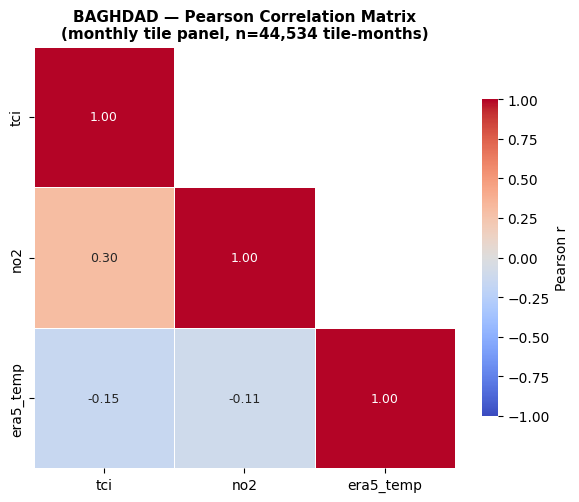

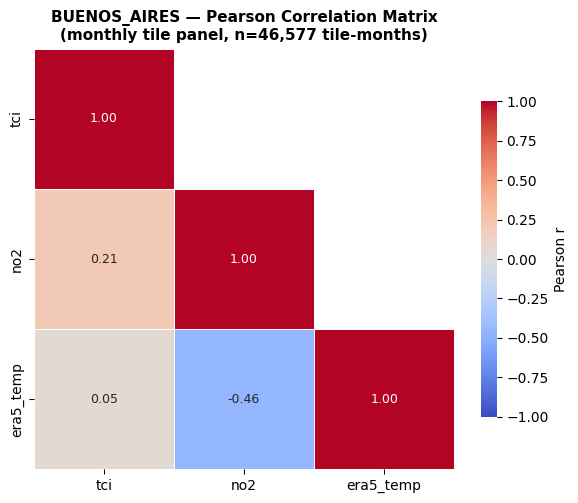

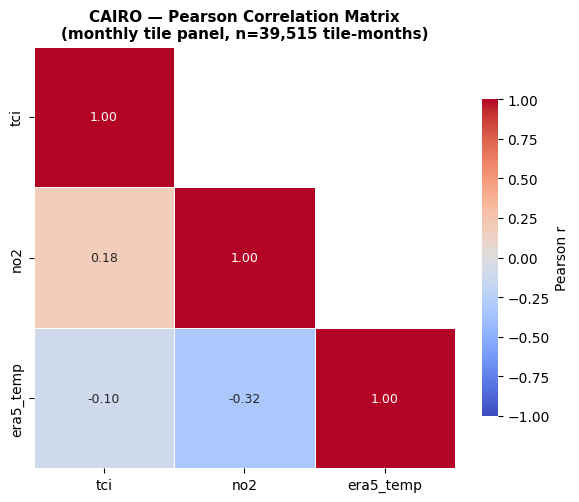

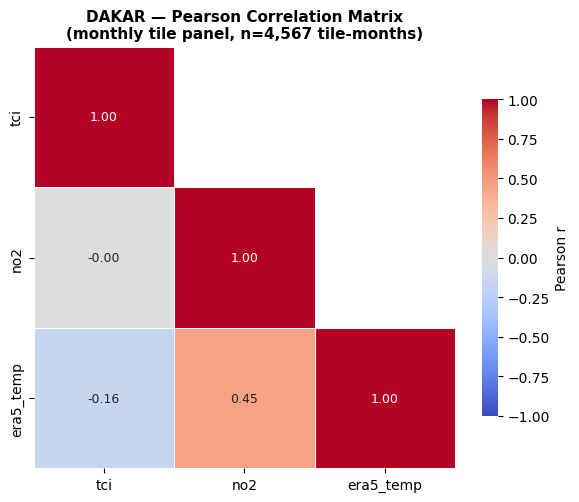

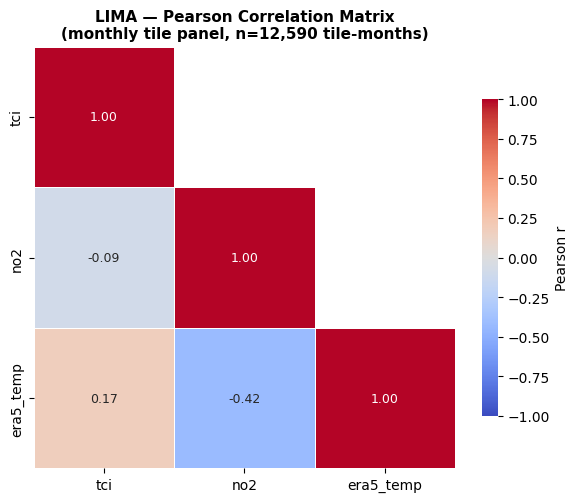

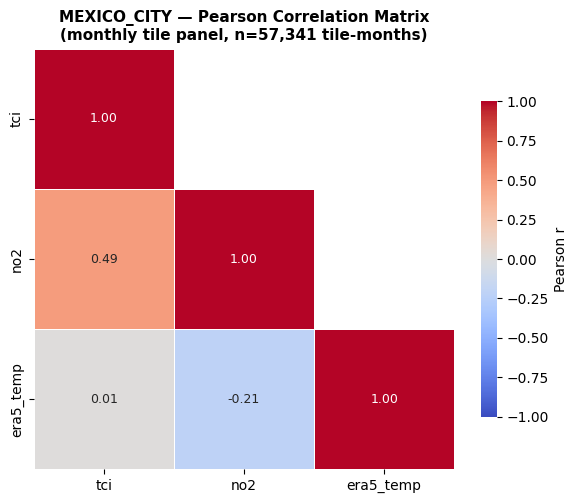

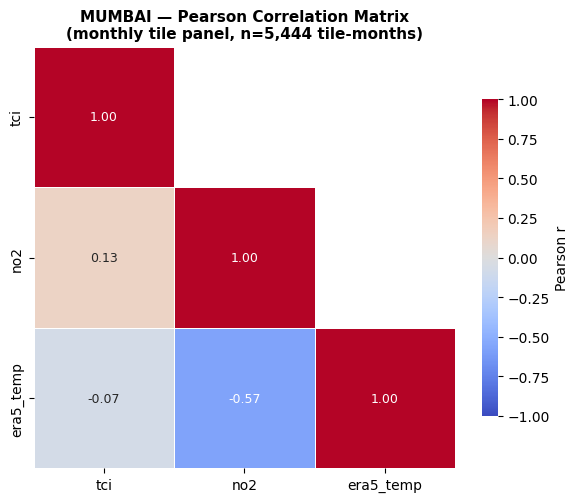

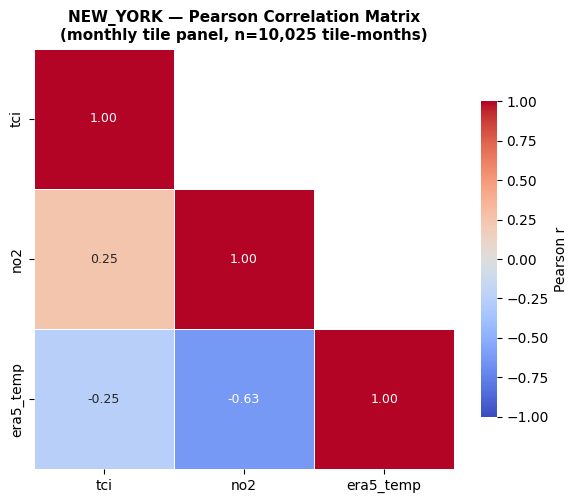

In [9]:
for city, corr_p in city_corr_pearson.items():
    n_feat = len(corr_p)
    fig, ax = plt.subplots(figsize=(max(6, n_feat * 0.9), max(5, n_feat * 0.8)))

    mask = np.triu(np.ones_like(corr_p, dtype=bool), k=1)
    sns.heatmap(
        corr_p, mask=mask, ax=ax, annot=True, fmt='.2f',
        cmap='coolwarm', vmin=-1, vmax=1, center=0,
        linewidths=0.5, square=True, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
        annot_kws={'fontsize': 9},
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(f'{city.upper()} — Pearson Correlation Matrix\n'
                 f'(monthly tile panel, n={len(city_panels[city]):,} tile-months)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DATA_ROOT / city / 'grid_panel' / f'{city}_correlation_heatmap.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 6. Feature Ranking vs TCI (per city)

Horizontal bar chart of every feature's Pearson correlation with TCI,
sorted by absolute strength, so the most TCI-relevant features are
immediately visible per city.

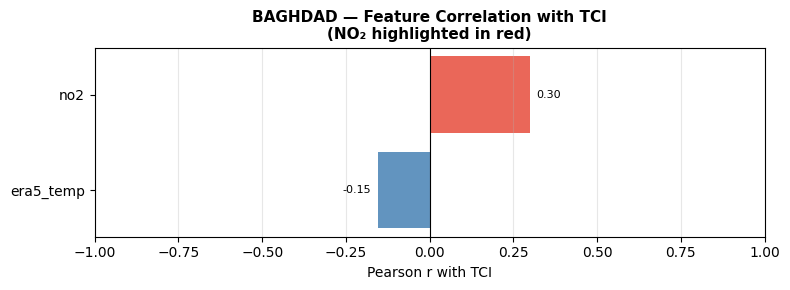

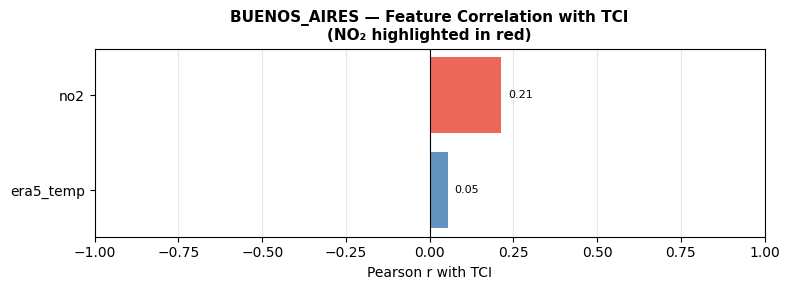

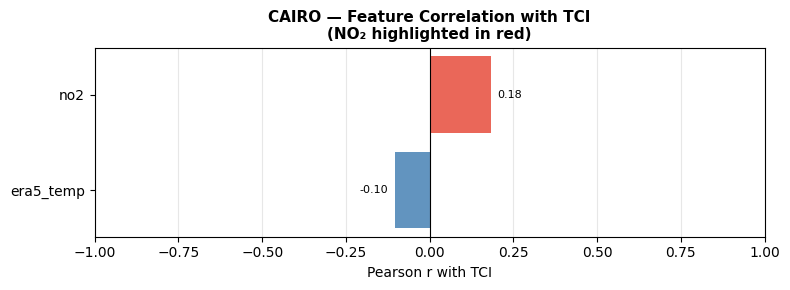

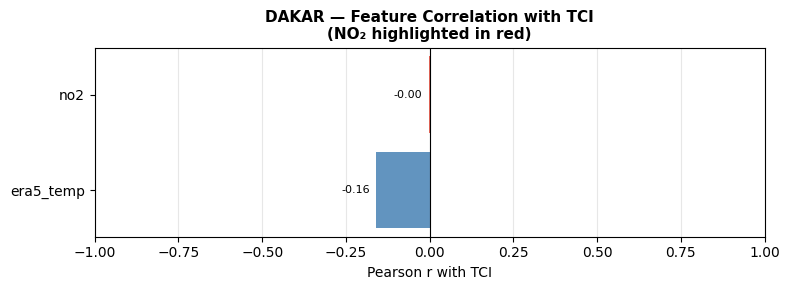

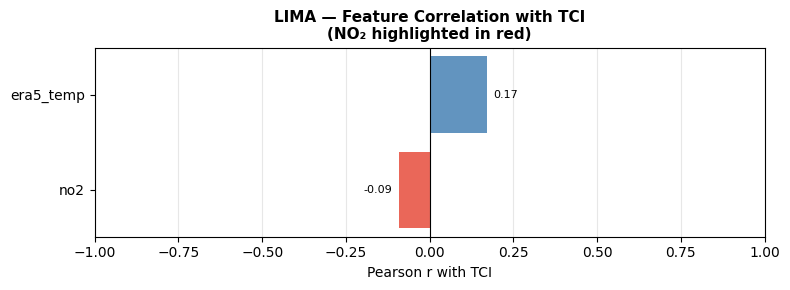

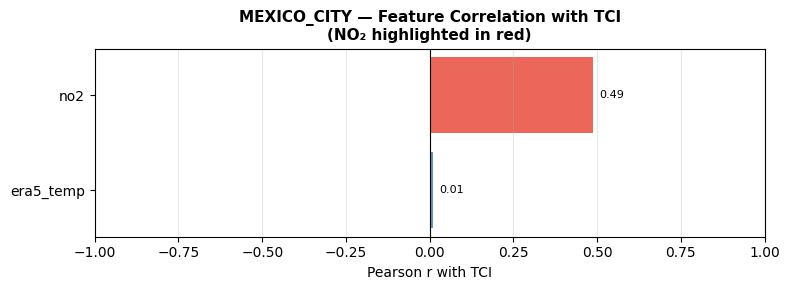

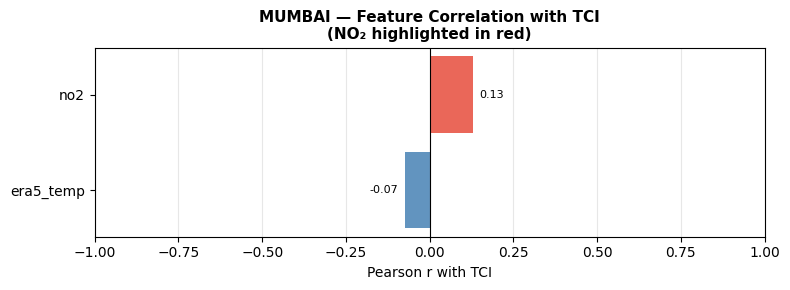

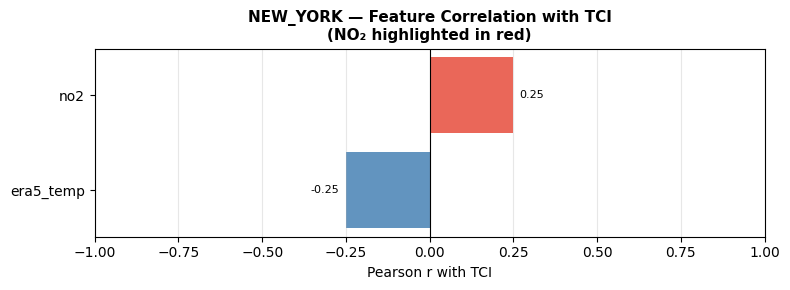

In [10]:
for city, tci_table in city_tci_corr.items():
    if tci_table.empty:
        continue
    plot_df = tci_table.dropna(subset=['pearson_r']).copy()
    if plot_df.empty:
        print(f'{city}: no feature pairs met MIN_PAIRS_FOR_CORR — skipping plot')
        continue

    plot_df = plot_df.sort_values('pearson_r')
    colors = ['#e74c3c' if f == NO2_COL else 'steelblue' for f in plot_df['feature']]

    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(plot_df))))
    bars = ax.barh(plot_df['feature'], plot_df['pearson_r'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Pearson r with TCI', fontsize=10)
    ax.set_title(f'{city.upper()} — Feature Correlation with TCI\n(NO₂ highlighted in red)',
                 fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    for bar, val in zip(bars, plot_df['pearson_r']):
        ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

    plt.tight_layout()
    plt.savefig(DATA_ROOT / city / 'grid_panel' / f'{city}_tci_feature_ranking.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 7. Pooled Analysis (All Cities Stacked)

Stacks every loaded city's monthly tile panel into one DataFrame and repeats
the correlation analysis on the pooled data. This is the relationship a
model trained across multiple cities (for the cross-city generalization
goal) would actually see.

**Caveat:** pooling assumes the *unconditional* relationship between
features and TCI is comparable across cities. If the per-city heatmaps above
show meaningfully different signs or magnitudes for a feature (especially
NO₂), the pooled number is an average that may not represent any single
city well — this is itself a useful diagnostic for the modelling notebooks.

In [11]:
# Only pool over the feature columns common to ALL loaded cities, so the
# pooled matrix isn't built on a column that's actually missing for some
# cities (which would otherwise just reduce N silently for that column).
common_cols = set.intersection(*[set(c) for c in city_feature_cols.values()]) if city_feature_cols else set()
common_cols = sorted(common_cols, key=lambda c: (c != TCI_COL, c))  # TCI first

dropped_cols = set.union(*[set(c) for c in city_feature_cols.values()]) - set(common_cols) if city_feature_cols else set()
if dropped_cols:
    print(f'⚠ Columns excluded from pooled analysis (not present in every city): {sorted(dropped_cols)}')
print(f'\nPooled feature columns ({len(common_cols)}): {common_cols}')

pooled_df = pd.concat(city_panels.values(), ignore_index=True)
print(f'Pooled panel: {len(pooled_df):,} tile-months across {len(city_panels)} cities')


Pooled feature columns (3): ['tci', 'era5_temp', 'no2']
Pooled panel: 220,593 tile-months across 8 cities


In [12]:
pooled_corr_pearson, pooled_n_pairs = pairwise_corr_with_n(pooled_df, common_cols, method='pearson')
pooled_corr_spearman, _              = pairwise_corr_with_n(pooled_df, common_cols, method='spearman')
pooled_tci_corr                      = tci_correlation_table(pooled_df, common_cols)

pooled_corr_pearson.to_csv(OUTPUT_ROOT / 'pooled_correlation_matrix_pearson.csv')
pooled_corr_spearman.to_csv(OUTPUT_ROOT / 'pooled_correlation_matrix_spearman.csv')
pooled_tci_corr.to_csv(OUTPUT_ROOT / 'pooled_tci_correlations.csv', index=False)

print('Pooled TCI correlation ranking (by |Pearson r|):')
print(pooled_tci_corr.round(3).to_string(index=False))

Pooled TCI correlation ranking (by |Pearson r|):
  feature  pearson_r  pearson_p  spearman_rho  spearman_p  n_pairs
      no2      0.303        0.0         0.371         0.0   220593
era5_temp     -0.070        0.0        -0.044         0.0   220593


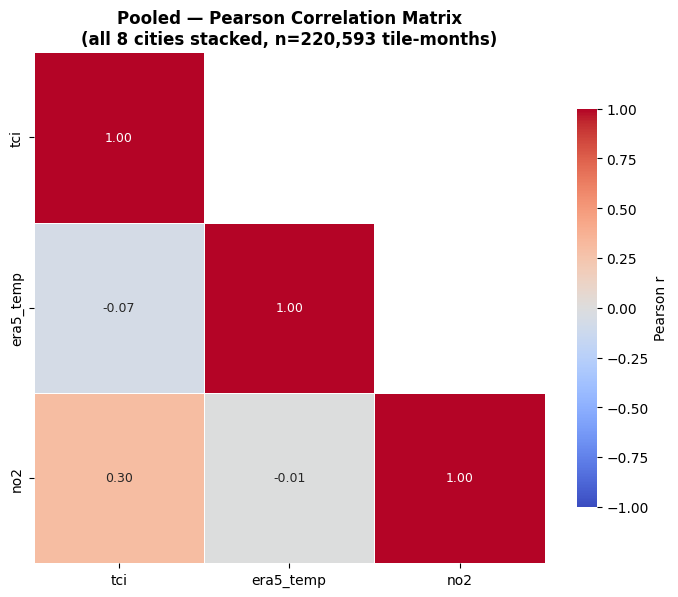

In [13]:
# ── 7.1 Pooled correlation heatmap ────────────────────────────────────────────
n_feat = len(pooled_corr_pearson)
fig, ax = plt.subplots(figsize=(max(7, n_feat * 0.9), max(6, n_feat * 0.8)))

mask = np.triu(np.ones_like(pooled_corr_pearson, dtype=bool), k=1)
sns.heatmap(
    pooled_corr_pearson, mask=mask, ax=ax, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
    annot_kws={'fontsize': 9},
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f'Pooled — Pearson Correlation Matrix\n'
             f'(all {len(city_panels)} cities stacked, n={len(pooled_df):,} tile-months)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'pooled_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

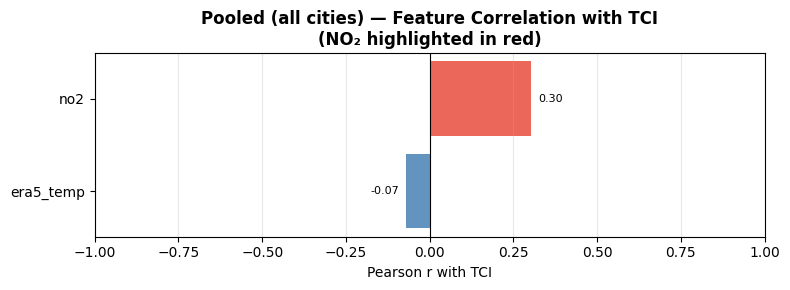

In [14]:
# ── 7.2 Pooled feature ranking vs TCI ─────────────────────────────────────────
plot_df = pooled_tci_corr.dropna(subset=['pearson_r']).sort_values('pearson_r').copy()
colors = ['#e74c3c' if f == NO2_COL else 'steelblue' for f in plot_df['feature']]

fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(plot_df))))
bars = ax.barh(plot_df['feature'], plot_df['pearson_r'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlim(-1, 1)
ax.set_xlabel('Pearson r with TCI', fontsize=10)
ax.set_title(f'Pooled (all cities) — Feature Correlation with TCI\n(NO₂ highlighted in red)',
             fontsize=12, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars, plot_df['pearson_r']):
    ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'pooled_tci_feature_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cross-City Comparison

The single most important diagnostic for cross-city generalization: does
each feature's correlation with TCI point the **same direction** and have
**similar magnitude** across cities? A dot plot lets you see, per feature,
the spread of correlation values across all loaded cities at a glance.

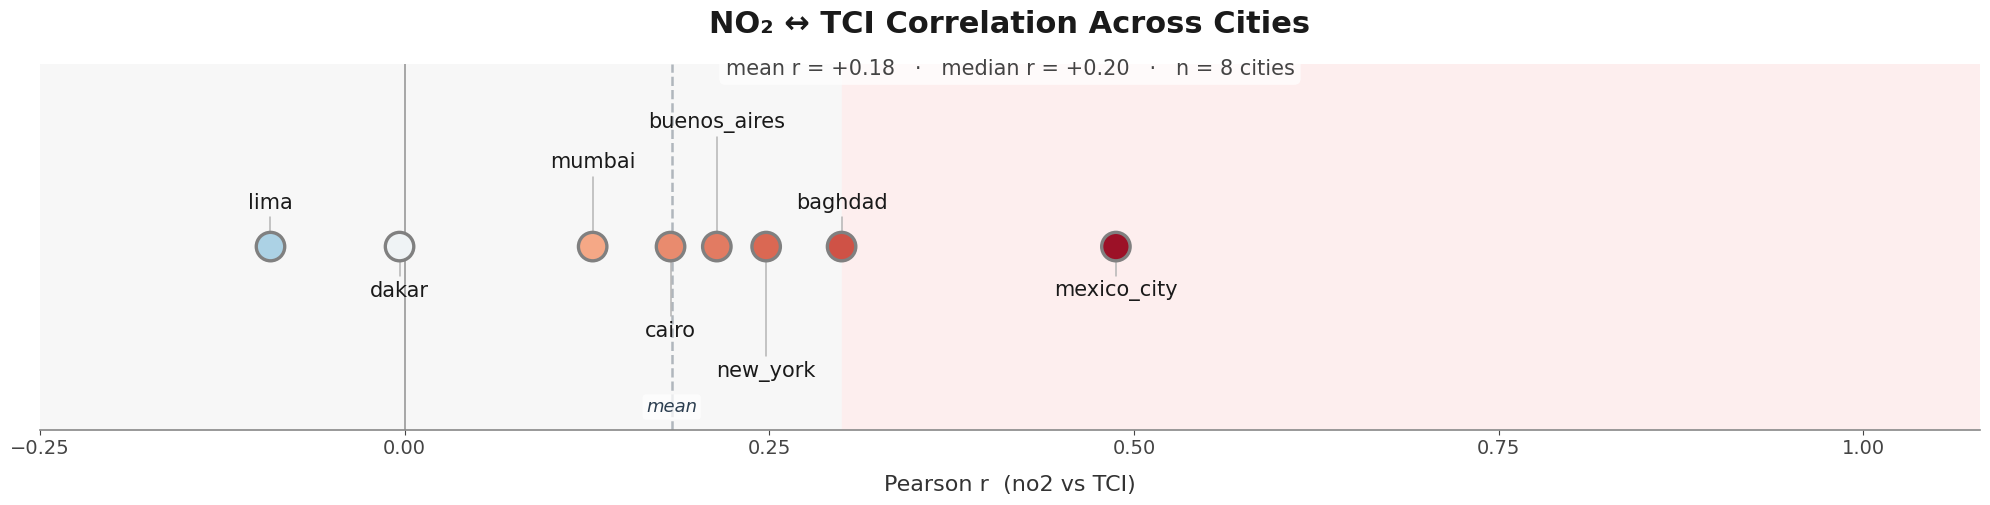

In [35]:
# ---- Pretty NO2-only cross-city correlation strip plot (large/wide poster version) ----
no2_rows = []
for city, tci_table in city_tci_corr.items():
    sub = tci_table[tci_table['feature'] == NO2_COL]
    if not sub.empty:
        no2_rows.append({'city': city, 'pearson_r': sub.iloc[0]['pearson_r']})

no2_df = pd.DataFrame(no2_rows).dropna(subset=['pearson_r'])

if not no2_df.empty:
    plt.rcParams['font.family'] = plt.rcParams.get('font.family', 'DejaVu Sans')

    vals = no2_df['pearson_r'].values
    names = no2_df['city'].values
    order = np.argsort(vals)
    vals_sorted = vals[order]
    names_sorted = names[order]
    n = len(vals_sorted)

    mean_r = vals.mean()
    median_r = np.median(vals)

    # crop the left tail (more horizontal spread), but never clip real data
    X_LEFT = min(-0.25, vals_sorted.min() - 0.05)
    X_RIGHT = 1.08

    # ---- deterministic row-stacking so labels never overlap ----
    # half-width recalibrated for the larger fontsize used below
    label_halfwidth = np.array([0.026 * max(len(c), 4) for c in names_sorted])
    MAX_ROWS = 6
    rows_assigned = np.zeros(n, dtype=int)
    sides = np.zeros(n, dtype=int)
    above_idx = list(range(0, n, 2))
    below_idx = list(range(1, n, 2))

    def _assign_side(idx_list, sign):
        row_edges = [-np.inf] * MAX_ROWS
        for i in idx_list:
            x, hw = vals_sorted[i], label_halfwidth[i]
            placed = False
            for row in range(MAX_ROWS):
                if x - hw > row_edges[row] + 0.018:
                    row_edges[row] = x + hw
                    rows_assigned[i] = row
                    sides[i] = sign
                    placed = True
                    break
            if not placed:
                rows_assigned[i] = MAX_ROWS - 1
                sides[i] = sign

    _assign_side(above_idx, 1)
    _assign_side(below_idx, -1)

    row_step = 0.55  # taller rows to match the bigger font
    n_rows_used = max(rows_assigned.max() + 1, 1)
    half_h = n_rows_used * row_step + 0.85  # extra room reserved for the mean label strip
    y_label = sides * (0.6 + rows_assigned * row_step)
    y_point = np.zeros(n)

    # wide, poster-scale figure
    fig, ax = plt.subplots(figsize=(20, max(4.2, 0.85 * n_rows_used + 2.6)))

    # background bands for r magnitude context, clipped to the cropped range
    for lo, hi, color in [(X_LEFT, -0.3, '#eef3fb'), (-0.3, 0.3, '#f7f7f7'), (0.3, X_RIGHT, '#fdeeee')]:
        ax.axvspan(max(lo, X_LEFT), min(hi, X_RIGHT), color=color, zorder=0)

    ax.axvline(0, color='#999999', lw=1.2, ls='-', zorder=1)

    # mean line: behind everything, faint, doesn't compete with data/text
    ax.axvline(mean_r, color='#2c3e50', lw=1.8, ls='--', zorder=0.5, alpha=0.35)

    # vivid, print-friendly colormap: contrast-stretched away from the midpoint
    t = np.interp(vals_sorted, [-1, 1], [0, 1])
    t_stretched = 0.5 + np.sign(t - 0.5) * (np.abs(t - 0.5) ** 0.6)
    t_stretched = np.clip(t_stretched, 0.04, 0.96)
    colors = plt.cm.RdBu_r(t_stretched)

    gap = 0.2
    for x, y, side in zip(vals_sorted, y_label, sides):
        ax.plot([x, x], [0.06 * side, y - gap * side], color='#b5b5b5',
                 lw=1.1, zorder=2, solid_capstyle='round')

    # bigger points
    ax.scatter(vals_sorted, y_point, s=420, c=colors, edgecolor='gray',
               linewidth=2.4, zorder=4)

    # bigger labels
    for v, y, name in zip(vals_sorted, y_label, names_sorted):
        ax.annotate(name, (v, y), fontsize=15, color='#1a1a1a',
                    ha='center', va='center', zorder=6, fontweight='medium')

    ax.set_xlim(X_LEFT, X_RIGHT)
    ax.set_ylim(-half_h, half_h)
    ax.set_yticks([])
    ax.set_xlabel(f'Pearson r  ({NO2_COL} vs TCI)', fontsize=16, color='#333333', labelpad=12)
    ax.set_xticks(np.arange(np.ceil(X_LEFT / 0.25) * 0.25, 1.01, 0.25))
    ax.tick_params(axis='x', labelsize=14, colors='#444444')

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#888888')
    ax.spines['bottom'].set_linewidth(1.2)

    ax.set_title('NO₂ ↔ TCI Correlation Across Cities', fontsize=22,
                 fontweight='bold', color='#1a1a1a', pad=22)

    ax.text(0.5, 0.97, f'mean r = {mean_r:+.2f}   ·   median r = {median_r:+.2f}   ·   n = {n} cities',
            transform=ax.transAxes, ha='center', fontsize=15, color='#444444', zorder=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.75))

    ax.annotate('mean', xy=(mean_r, -half_h + 0.07), xytext=(mean_r, -half_h + 0.24),
                fontsize=13, color='#2c3e50', ha='center', style='italic', zorder=10,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.75))

    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / 'tci_no2_correlation_by_city.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No per-city NO2 correlation data available to plot.')

In [ ]:
# ── 8.1 Same comparison as a wide table (rows = feature, cols = city) ─────────
if not cross_city_df.empty:
    wide = cross_city_df.pivot(index='feature', columns='city', values='pearson_r')
    wide['mean'] = wide.mean(axis=1, skipna=True)
    wide['std']  = wide.drop(columns='mean').std(axis=1, skipna=True)
    wide = wide.reindex(wide['mean'].abs().sort_values(ascending=False).index)
    wide.to_csv(OUTPUT_ROOT / 'tci_correlation_by_city_wide.csv')
    print('Feature ↔ TCI correlation by city (sorted by |mean| across cities):')
    print(wide.round(3).to_string())

Feature ↔ TCI correlation by city (sorted by |mean| across cities):
city       baghdad  buenos_aires  cairo  dakar   lima  mexico_city  mumbai  new_york   mean    std
feature                                                                                           
no2          0.300         0.214  0.182 -0.003 -0.092        0.488   0.129     0.248  0.183  0.179
era5_temp   -0.155         0.054 -0.103 -0.159  0.170        0.009  -0.074    -0.251 -0.064  0.135


## 9. Multicollinearity Check (Feature × Feature, Pooled)

Pairs of *features* (excluding TCI itself) with a high absolute pooled
correlation are flagged. This doesn't block anything in this notebook — it's
a heads-up for the modelling notebooks, where highly collinear features can
distort coefficient interpretation in OLS/Lasso (relevant to the
interpretability requirement) even if they don't hurt LightGBM's predictive
accuracy.

In [ ]:
COLLINEARITY_THRESHOLD = 0.7  # |r| at or above this is flagged

feature_only_cols = [c for c in common_cols if c != TCI_COL]
flagged = []
for i, ci in enumerate(feature_only_cols):
    for cj in feature_only_cols[i + 1:]:
        r = pooled_corr_pearson.loc[ci, cj]
        if pd.notna(r) and abs(r) >= COLLINEARITY_THRESHOLD:
            flagged.append({'feature_1': ci, 'feature_2': cj, 'pearson_r': r})

flagged_df = pd.DataFrame(flagged).sort_values('pearson_r', key=lambda s: s.abs(), ascending=False) \
             if flagged else pd.DataFrame(columns=['feature_1', 'feature_2', 'pearson_r'])

if flagged_df.empty:
    print(f'No feature pairs at or above |r| = {COLLINEARITY_THRESHOLD} — no multicollinearity flags.')
else:
    print(f'Feature pairs with |Pearson r| ≥ {COLLINEARITY_THRESHOLD} (pooled, excluding TCI):')
    print(flagged_df.round(3).to_string(index=False))
    flagged_df.to_csv(OUTPUT_ROOT / 'multicollinearity_flags.csv', index=False)

No feature pairs at or above |r| = 0.7 — no multicollinearity flags.


## 10. Summary

In [ ]:
print('=' * 70)
print('CORRELATION ANALYSIS SUMMARY')
print('=' * 70)
print(f'Cities loaded        : {len(city_panels)} / {len(CITIES)} — {list(city_panels.keys())}')
print(f'Pooled tile-months   : {len(pooled_df):,}')
print(f'Common feature cols  : {common_cols}')
if dropped_cols:
    print(f'Dropped from pooling : {sorted(dropped_cols)} (not present in every city)')

if not pooled_tci_corr.empty:
    top = pooled_tci_corr.dropna(subset=['pearson_r']).iloc[0]
    print(f"\nStrongest pooled correlate of TCI : {top['feature']} "
          f"(Pearson r = {top['pearson_r']:.3f}, Spearman ρ = {top['spearman_rho']:.3f})")

if NO2_COL in pooled_tci_corr['feature'].values:
    no2_row = pooled_tci_corr[pooled_tci_corr['feature'] == NO2_COL].iloc[0]
    print(f"NO₂ ↔ TCI (pooled)                : Pearson r = {no2_row['pearson_r']:.3f}, "
          f"Spearman ρ = {no2_row['spearman_rho']:.3f}, p = {no2_row['pearson_p']:.3g}, "
          f"n = {no2_row['n_pairs']:,}")

if not flagged_df.empty:
    print(f"\n⚠ {len(flagged_df)} feature pair(s) flagged for multicollinearity "
          f"(|r| ≥ {COLLINEARITY_THRESHOLD}) — see multicollinearity_flags.csv")

print(f'\nAll outputs saved under:')
print(f'  Per-city : data/processed/{{city}}/grid_panel/')
print(f'  Pooled   : {OUTPUT_ROOT}')

CORRELATION ANALYSIS SUMMARY
Cities loaded        : 8 / 17 — ['baghdad', 'buenos_aires', 'cairo', 'dakar', 'lima', 'mexico_city', 'mumbai', 'new_york']
Pooled tile-months   : 220,593
Common feature cols  : ['tci', 'era5_temp', 'no2']

Strongest pooled correlate of TCI : no2 (Pearson r = 0.303, Spearman ρ = 0.371)
NO₂ ↔ TCI (pooled)                : Pearson r = 0.303, Spearman ρ = 0.371, p = 0, n = 220,593

All outputs saved under:
  Per-city : data/processed/{city}/grid_panel/
  Pooled   : /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/outputs/correlation_analysis


## 11. Between-Tile vs Within-Tile Decomposition

### Why this section exists
Sections 4–8 above compute a **pooled** correlation: every tile-month row is
treated as one point in a single scatter cloud. That number conflates two
very different sources of co-variation:

- **Between-tile (cross-sectional)** — tile A simply *is* a higher-NO₂,
  higher-TCI place than tile B, as a fairly static characteristic. This
  shows up in a pooled correlation even if NO₂ and TCI never move together
  over time within any single tile.
- **Within-tile (temporal)** — for a *given* tile, do its month-to-month
  ups and downs in NO₂ line up with its month-to-month ups and downs in
  TCI? This is the closer-to-causal, "does congestion track pollution over
  time" question, and it's what the per-tile map in Section 12 is built on.

We isolate the within-tile signal by **demeaning**: subtracting each tile's
own mean from every variable before correlating. This is the standard
fixed-effects / panel-data decomposition (the within-tile correlation is
mathematically equivalent to the correlation you'd get from a tile
fixed-effects regression).

$$\text{within}_{i,t} = x_{i,t} - \bar{x}_i \qquad \text{where } \bar{x}_i \text{ is tile } i\text{'s own mean across its months}$$

The between-tile correlation is the complementary piece: correlate each
tile's **mean** values against each other (one point per tile, not per
tile-month).

In [ ]:
def decompose_between_within(df: pd.DataFrame, cols: list[str], id_col: str = 'spatial_id'):
    """
    Split a tile x month panel into between-tile and within-tile components
    for each column in `cols`.

    Returns:
        between_df : one row per tile, columns = tile means (for the between-tile correlation)
        within_df  : one row per tile-month, columns = value minus that tile's own mean
                     (for the within-tile correlation)
    """
    tile_means = df.groupby(id_col)[cols].transform('mean')
    within_df  = df[cols] - tile_means
    within_df[id_col] = df[id_col].values

    between_df = df.groupby(id_col)[cols].mean().reset_index()

    return between_df, within_df


def corr_table_generic(df: pd.DataFrame, cols: list[str], target: str, label: str) -> pd.DataFrame:
    """Same logic as tci_correlation_table() but reusable for between/within frames."""
    rows = []
    for col in cols:
        if col == target:
            continue
        pair = df[[target, col]].dropna()
        n_pairs = len(pair)
        if n_pairs < MIN_PAIRS_FOR_CORR or pair[target].std() == 0 or pair[col].std() == 0:
            rows.append({'feature': col, 'pearson_r': np.nan, 'pearson_p': np.nan, 'n_pairs': n_pairs})
            continue
        r, p = stats.pearsonr(pair[target], pair[col])
        rows.append({'feature': col, 'pearson_r': r, 'pearson_p': p, 'n_pairs': n_pairs})
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.reindex(out['pearson_r'].abs().sort_values(ascending=False).index).reset_index(drop=True)
    out.insert(0, 'decomposition', label)
    return out


print('✓ Decomposition helpers defined')

✓ Decomposition helpers defined


In [ ]:
# Run the decomposition on the pooled panel, over the common feature columns
between_df, within_df = decompose_between_within(pooled_df, common_cols, id_col='spatial_id')

between_tci_corr = corr_table_generic(between_df, common_cols, TCI_COL, 'between (cross-sectional)')
within_tci_corr  = corr_table_generic(within_df,  common_cols, TCI_COL, 'within (temporal)')
pooled_tci_corr_labelled = pooled_tci_corr.copy()
pooled_tci_corr_labelled.insert(0, 'decomposition', 'pooled (conflated)')

decomposition_compare = pd.concat([
    pooled_tci_corr_labelled[['decomposition', 'feature', 'pearson_r', 'pearson_p', 'n_pairs']],
    between_tci_corr,
    within_tci_corr,
], ignore_index=True)

decomposition_compare.to_csv(OUTPUT_ROOT / 'tci_correlation_decomposition.csv', index=False)

print('TCI correlation by decomposition (pooled vs between-tile vs within-tile):')
print(decomposition_compare.round(3).to_string(index=False))

TCI correlation by decomposition (pooled vs between-tile vs within-tile):
            decomposition   feature  pearson_r  pearson_p  n_pairs
       pooled (conflated)       no2      0.303      0.000   220593
       pooled (conflated) era5_temp     -0.070      0.000   220593
between (cross-sectional)       no2      0.395      0.000    21105
between (cross-sectional) era5_temp      0.014      0.046    21105
        within (temporal) era5_temp     -0.194      0.000   220593
        within (temporal)       no2      0.080      0.000   220593


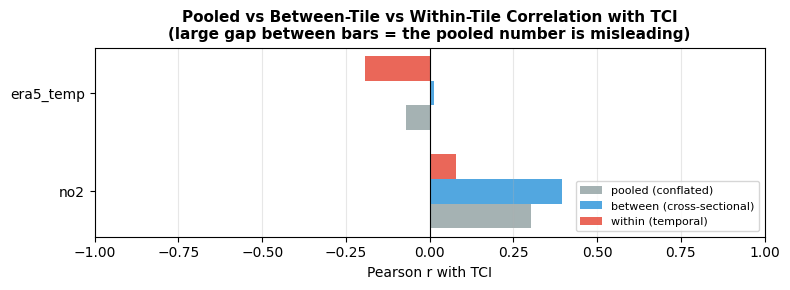


NO₂ specifically:
decomposition
pooled (conflated)           0.303
between (cross-sectional)    0.395
within (temporal)            0.080


In [ ]:
# ── 11.1 Visual comparison: pooled vs between vs within, per feature ─────────
pivot_decomp = decomposition_compare.pivot(index='feature', columns='decomposition', values='pearson_r')
col_order = [c for c in ['pooled (conflated)', 'between (cross-sectional)', 'within (temporal)'] if c in pivot_decomp.columns]
pivot_decomp = pivot_decomp[col_order]
pivot_decomp = pivot_decomp.reindex(pivot_decomp.abs().max(axis=1).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, max(3, 0.6 * len(pivot_decomp))))
y = np.arange(len(pivot_decomp))
width = 0.25
colors = {'pooled (conflated)': '#95a5a6', 'between (cross-sectional)': '#3498db', 'within (temporal)': '#e74c3c'}

for i, col in enumerate(col_order):
    offset = (i - (len(col_order) - 1) / 2) * width
    ax.barh(y + offset, pivot_decomp[col], height=width, label=col,
            color=colors.get(col, 'grey'), alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(pivot_decomp.index)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlim(-1, 1)
ax.set_xlabel('Pearson r with TCI', fontsize=10)
ax.set_title('Pooled vs Between-Tile vs Within-Tile Correlation with TCI\n'
             '(large gap between bars = the pooled number is misleading)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'tci_correlation_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Headline NO2 readout
if NO2_COL in pivot_decomp.index:
    print('\nNO₂ specifically:')
    print(pivot_decomp.loc[NO2_COL].round(3).to_string())

## 12. Per-Tile NO₂–TCI Correlation & Grid Map

### What this computes
For **every individual tile**, this correlates that tile's own monthly NO₂
series against its own monthly TCI series — i.e. one correlation per
`spatial_id`, using only that tile's months as data points. This is the
finest-grained version of the "within-tile" idea from Section 11, but kept
per-tile (not collapsed to a single city-wide number) so it can be mapped
spatially: which parts of the city show a tight NO₂–TCI relationship over
time, and which don't?

### Caveat — read before interpreting the map
Each tile's correlation is computed from only as many points as that tile
has valid months (typically ≤ 12 for one year of data). Correlations from
such small samples are **noisy**: a single unusual month can swing a tile's
r substantially, and statistical significance (`p`) will often not survive
multiple-comparison correction across hundreds/thousands of tiles. Treat the
map as descriptive / exploratory — useful for spotting spatial *patterns*
(e.g. arterial corridors vs residential tiles) — not as a set of
independently reliable per-tile estimates. `MIN_MONTHS_FOR_TILE_CORR` below
sets a floor on how many valid months a tile needs before we even attempt a
correlation for it; tiles below that show as grey ("insufficient data") on
the map rather than a number computed from 2–3 points.

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# USER INPUTS — Section 12
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Minimum valid (non-NaN, paired) months a tile must have before we compute
# a per-tile correlation for it at all. Below this, the tile is marked NaN
# (shown as grey / "insufficient data" on the map) rather than computed from
# too few points.
MIN_MONTHS_FOR_TILE_CORR = 6

# Correlation method for the per-tile map: 'pearson' or 'spearman'.
TILE_CORR_METHOD = 'pearson'

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f'Minimum months per tile : {MIN_MONTHS_FOR_TILE_CORR}')
print(f'Correlation method      : {TILE_CORR_METHOD}')

Minimum months per tile : 6
Correlation method      : pearson


In [ ]:
def per_tile_correlation(df: pd.DataFrame, col_a: str, col_b: str,
                          id_col: str = 'spatial_id',
                          min_months: int = MIN_MONTHS_FOR_TILE_CORR,
                          method: str = TILE_CORR_METHOD) -> pd.DataFrame:
    """
    Compute one correlation per tile between col_a and col_b, using only
    that tile's own monthly observations.

    A tile gets NaN if it has fewer than `min_months` valid paired
    observations, or if either variable is constant within that tile
    (correlation undefined).
    """
    rows = []
    for tile_id, g in df.groupby(id_col):
        pair = g[[col_a, col_b]].dropna()
        n = len(pair)
        if n < min_months or pair[col_a].std() == 0 or pair[col_b].std() == 0:
            rows.append({id_col: tile_id, 'r': np.nan, 'p': np.nan, 'n_months': n})
            continue
        if method == 'pearson':
            r, p = stats.pearsonr(pair[col_a], pair[col_b])
        else:
            r, p = stats.spearmanr(pair[col_a], pair[col_b])
        rows.append({id_col: tile_id, 'r': r, 'p': p, 'n_months': n})
    return pd.DataFrame(rows)


city_tile_corr: dict[str, pd.DataFrame] = {}

for city, df in city_panels.items():
    cols = city_feature_cols[city]
    if NO2_COL not in cols or TCI_COL not in cols:
        print(f'{city:<15} ⚠ skipped — no2 or tci column not present')
        continue

    tile_corr = per_tile_correlation(df, NO2_COL, TCI_COL)
    city_tile_corr[city] = tile_corr

    out_path = DATA_ROOT / city / 'grid_panel' / f'{city}_tile_no2_tci_correlation.csv'
    tile_corr.to_csv(out_path, index=False)

    n_valid = tile_corr['r'].notna().sum()
    print(f'{city:<15} {n_valid:>4,} / {len(tile_corr):,} tiles with a valid correlation  '
          f'(median r = {tile_corr["r"].median():.3f})  → saved {out_path.name}')

baghdad         3,805 / 4,277 tiles with a valid correlation  (median r = 0.140)  → saved baghdad_tile_no2_tci_correlation.csv
buenos_aires    3,963 / 4,226 tiles with a valid correlation  (median r = -0.151)  → saved buenos_aires_tile_no2_tci_correlation.csv
cairo           3,407 / 4,025 tiles with a valid correlation  (median r = 0.378)  → saved cairo_tile_no2_tci_correlation.csv
dakar            393 / 410 tiles with a valid correlation  (median r = -0.124)  → saved dakar_tile_no2_tci_correlation.csv
lima            1,058 / 1,132 tiles with a valid correlation  (median r = -0.491)  → saved lima_tile_no2_tci_correlation.csv
mexico_city     4,953 / 5,580 tiles with a valid correlation  (median r = 0.333)  → saved mexico_city_tile_no2_tci_correlation.csv
mumbai           523 / 613 tiles with a valid correlation  (median r = 0.320)  → saved mumbai_tile_no2_tci_correlation.csv
new_york         836 / 842 tiles with a valid correlation  (median r = 0.308)  → saved new_york_tile_no2_tci_corr

### 12.1 Grid map — NO₂–TCI correlation per tile

Joins the per-tile correlation table to each city's grid geometry
(`{city}_grid_geometry.gpkg`, produced by `01b`) and renders a choropleth.
Tiles with insufficient data (below `MIN_MONTHS_FOR_TILE_CORR`) are shown in
grey rather than omitted, so the map is honest about coverage gaps.

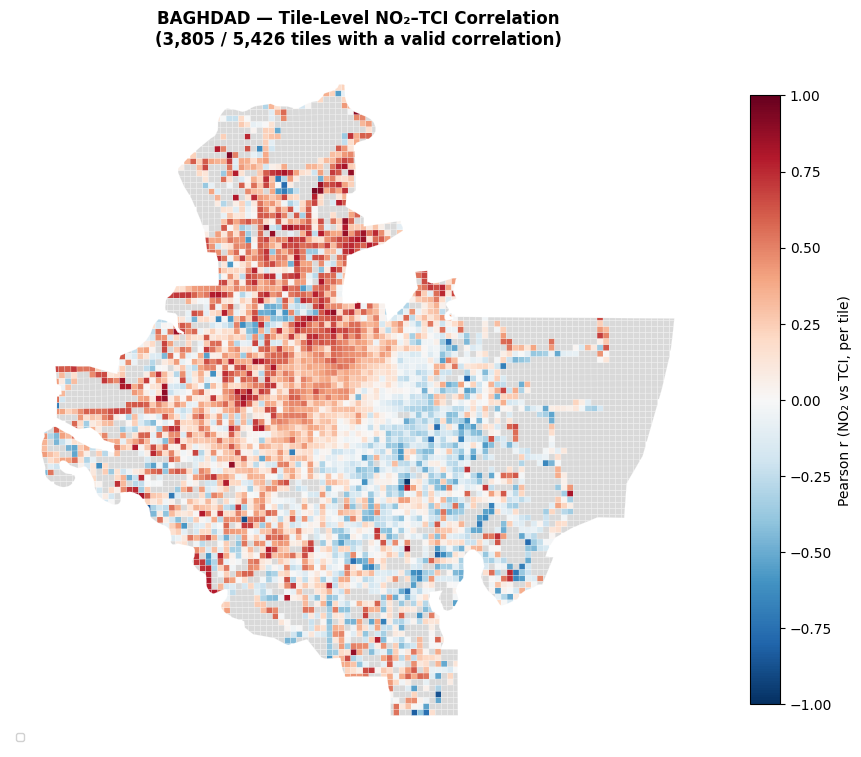

  → saved /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/../baghdad_tile_no2_tci_correlation_map.pdf


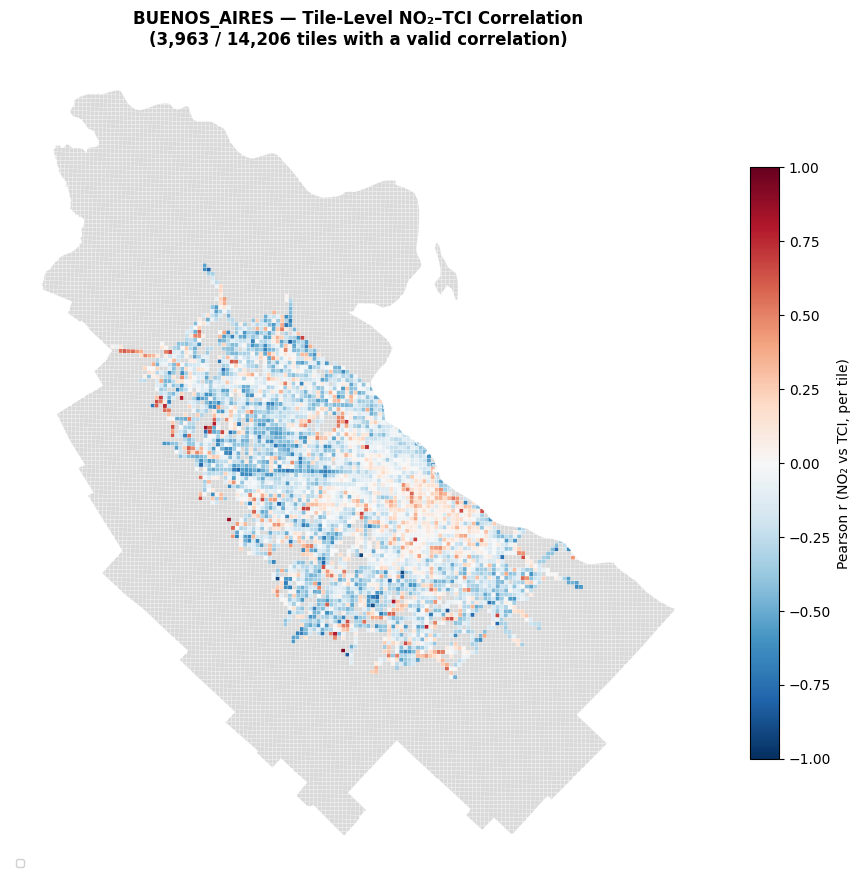

  → saved /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/../buenos_aires_tile_no2_tci_correlation_map.pdf


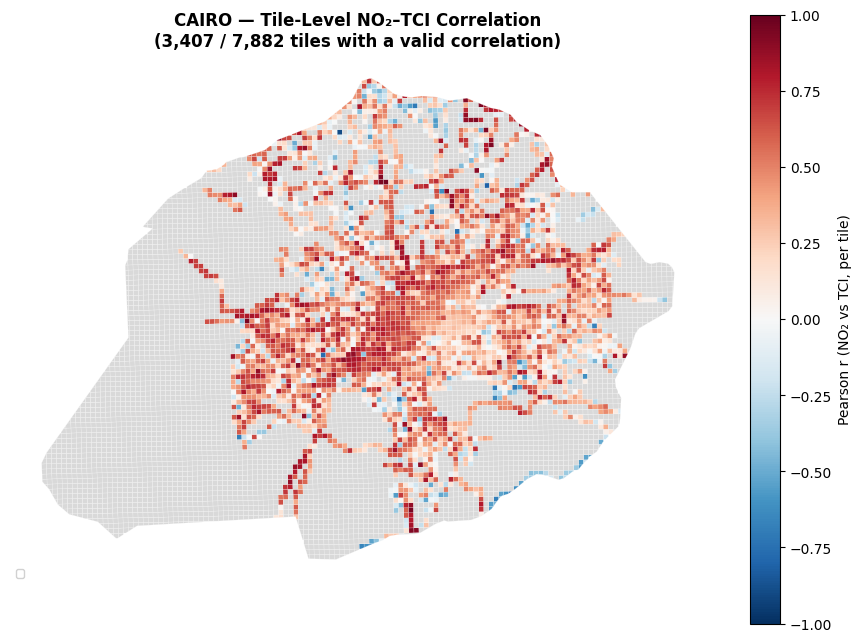

  → saved /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/../cairo_tile_no2_tci_correlation_map.pdf


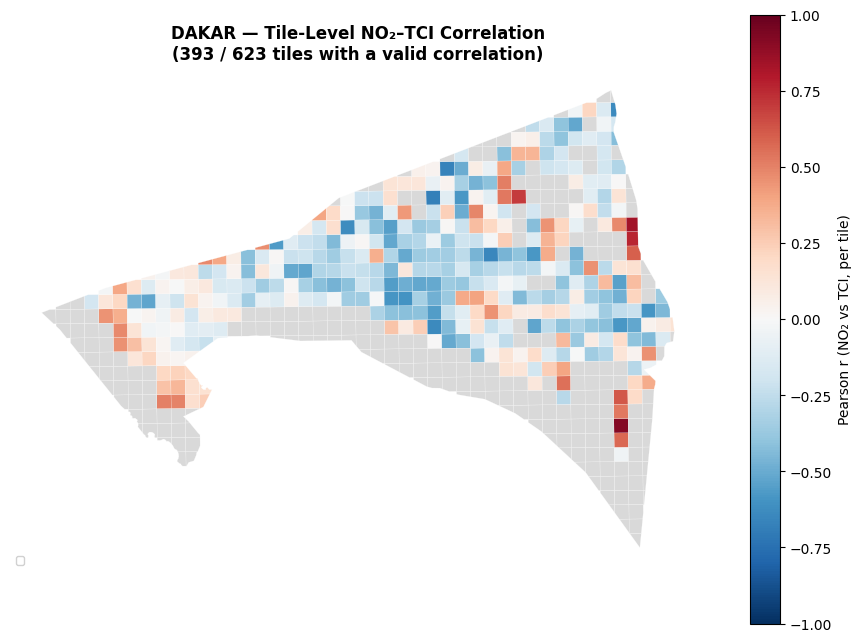

  → saved /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/../dakar_tile_no2_tci_correlation_map.pdf


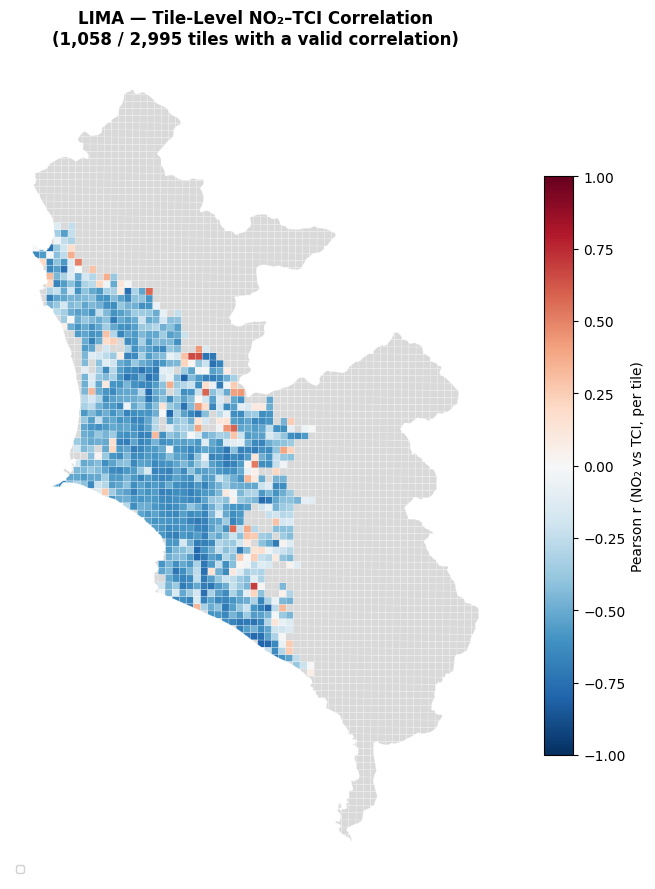

  → saved /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/../lima_tile_no2_tci_correlation_map.pdf


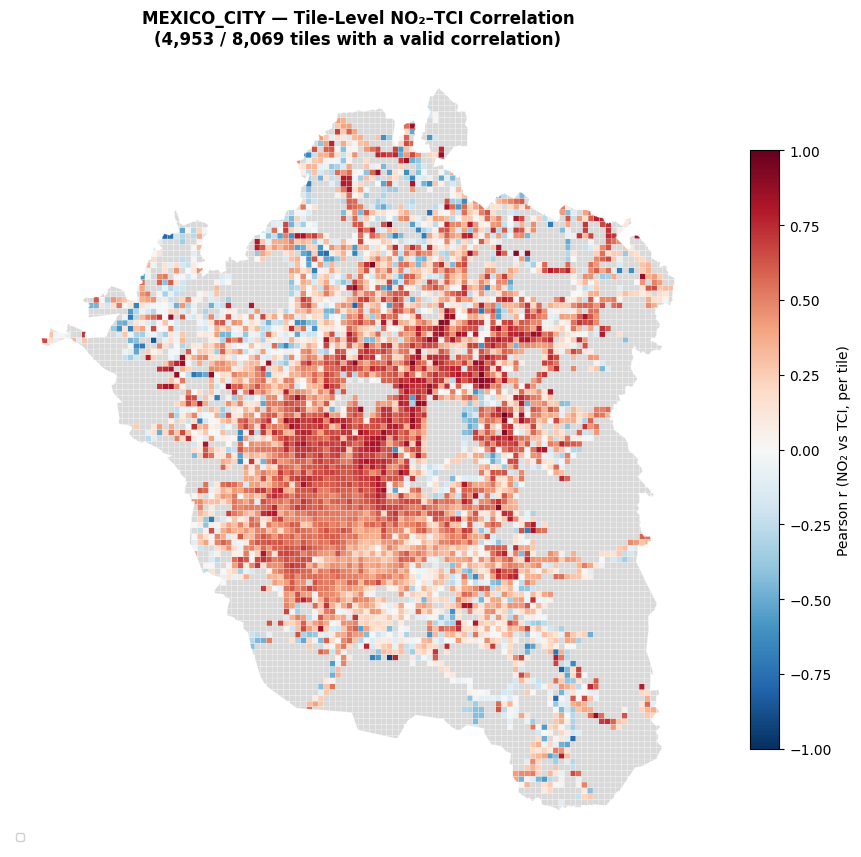

  → saved /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/../mexico_city_tile_no2_tci_correlation_map.pdf


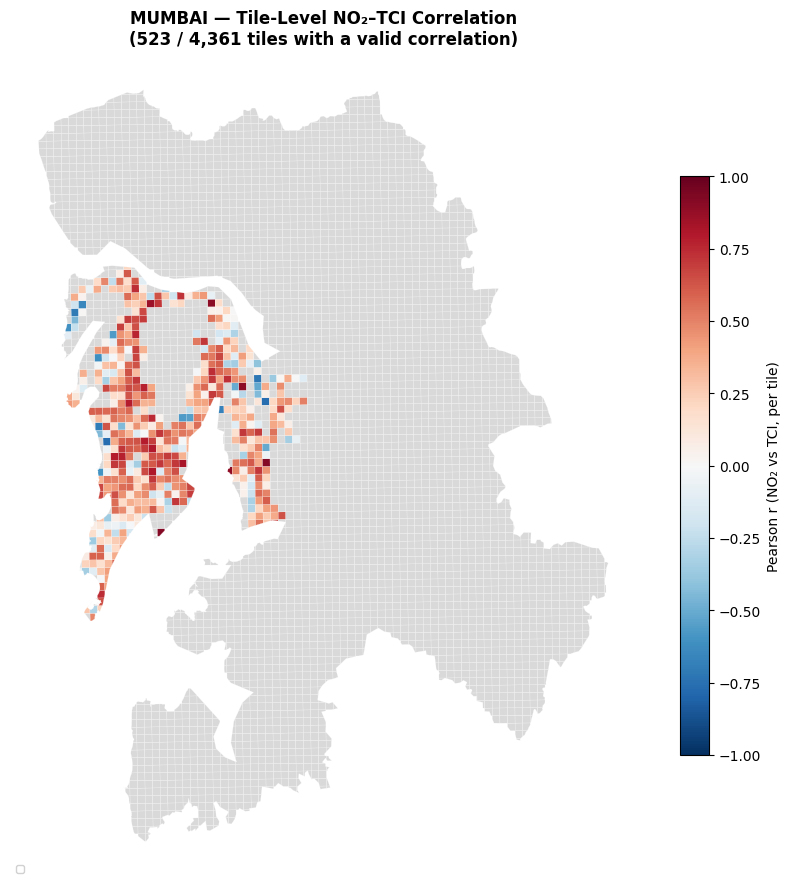

  → saved /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/../mumbai_tile_no2_tci_correlation_map.pdf


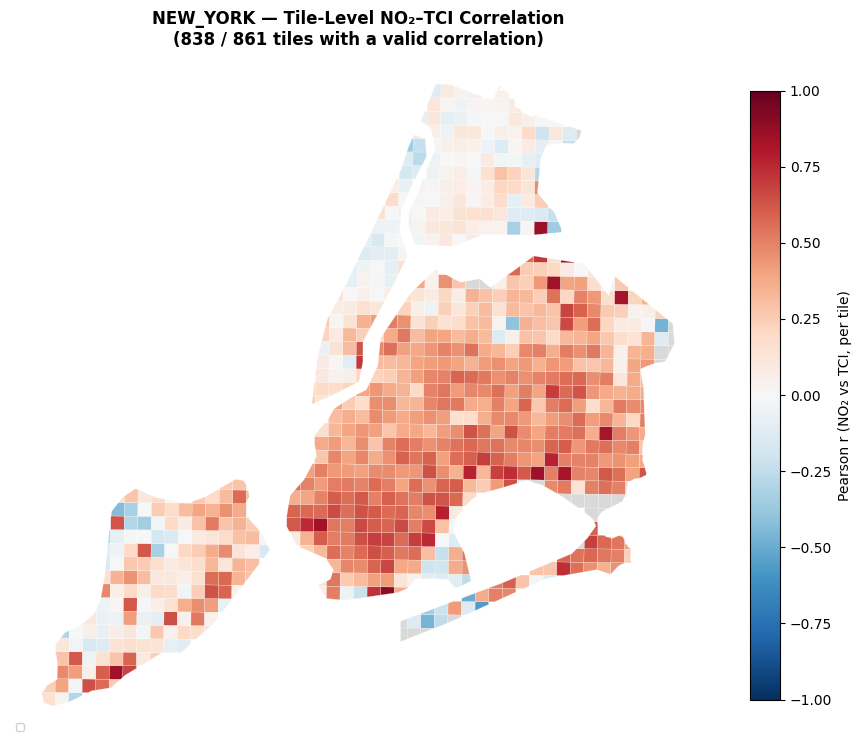

  → saved /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/processed/../new_york_tile_no2_tci_correlation_map.pdf


In [ ]:
def load_grid_geometry(city: str):
    """Load the 01b geometry lookup for a city, or None if not found."""
    path = DATA_ROOT / city / 'grid_panel' / f'{city}_grid_geometry.gpkg'
    if not path.exists():
        return None
    return gpd.read_file(path)


if not GEOPANDAS_AVAILABLE:
    print('⚠ geopandas not available — skipping grid maps in this section. '
          'Per-tile correlation CSVs were still saved above (Section 12, first cell) '
          'and can be mapped separately (e.g. in QGIS) by joining on spatial_id to '
          '{city}_grid_geometry.gpkg.')
else:
    for city, tile_corr in city_tile_corr.items():
        geom = load_grid_geometry(city)
        if geom is None:
            print(f'{city:<15} ⚠ no grid geometry file found — skipping map '
                  f'(expected at data/processed/{city}/grid_panel/{city}_grid_geometry.gpkg)')
            continue

        merged = geom.merge(tile_corr, on='spatial_id', how='left')
        n_mapped = merged['r'].notna().sum()
        n_total  = len(merged)

        fig, ax = plt.subplots(figsize=(9, 9))
        merged.plot(
            column='r', ax=ax, cmap='RdBu_r', vmin=-1, vmax=1,
            edgecolor='white', linewidth=0.15, legend=True,
            legend_kwds={'label': f'{TILE_CORR_METHOD.capitalize()} r (NO₂ vs TCI, per tile)',
                         'shrink': 0.7},
            missing_kwds={'color': '#d9d9d9', 'edgecolor': 'white', 'linewidth': 0.15,
                          'label': f'insufficient data (<{MIN_MONTHS_FOR_TILE_CORR} months)'},
        )
        ax.set_title(f'{city.upper()} — Tile-Level NO₂–TCI Correlation\n'
                     f'({n_mapped:,} / {n_total:,} tiles with a valid correlation)',
                     fontsize=12, fontweight='bold')
        ax.set_axis_off()
        ax.legend(loc='lower left', fontsize=8, framealpha=0.9)

        plt.tight_layout()
        out_path = DATA_ROOT / city / 'grid_panel' / f'{city}_tile_no2_tci_correlation_map.pdf'
        plt.savefig(out_path, bbox_inches='tight')
        plt.show()
        print(f'  → saved {out_path}')


### 12.2 Distribution of per-tile correlations (sanity check alongside the map)

A histogram makes it easy to see, independent of geography, whether most
tiles agree on a sign and rough magnitude (a tight, one-sided distribution)
or whether the city is a genuine mix of positive- and negative-correlation
tiles (a spread distribution straddling zero) — which the map's color
pattern should visually corroborate.

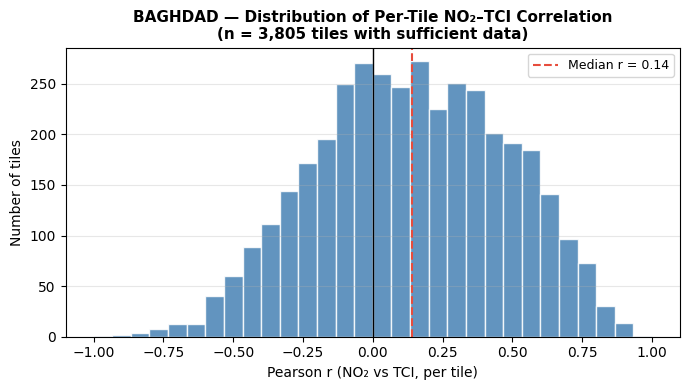

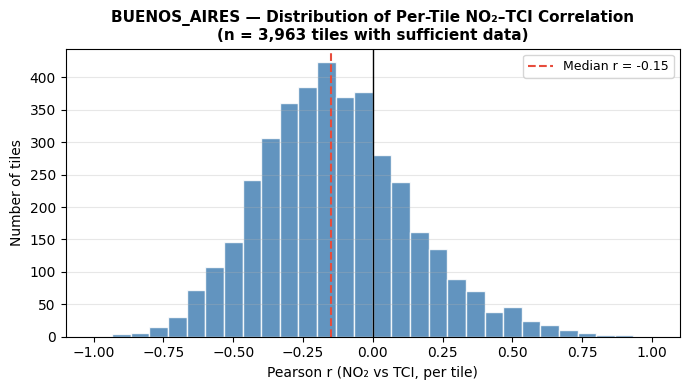

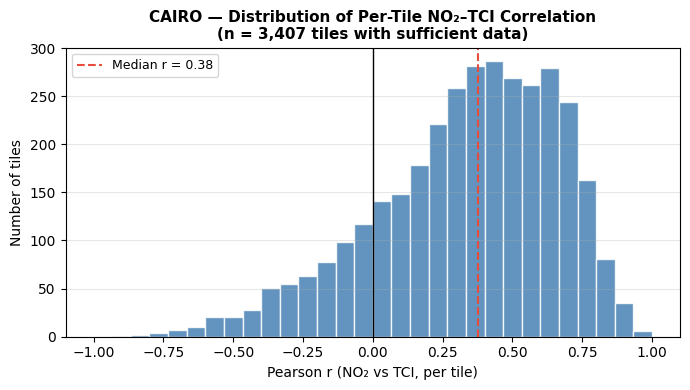

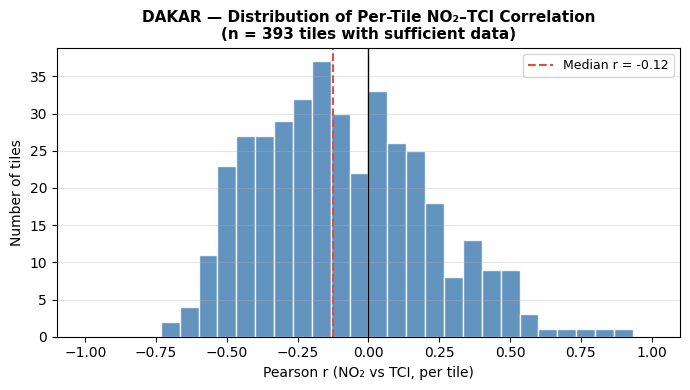

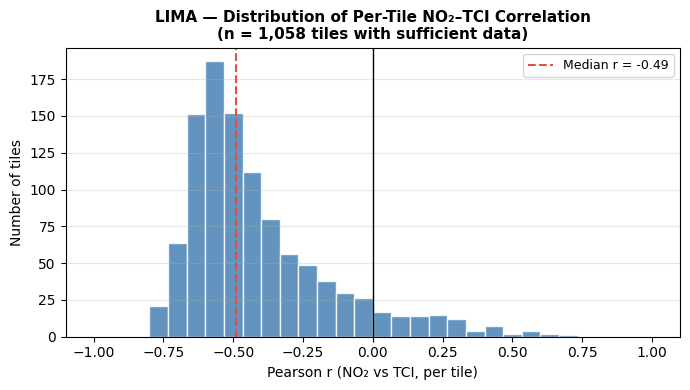

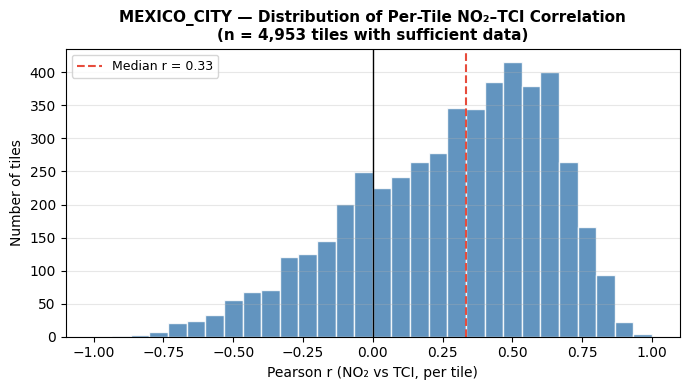

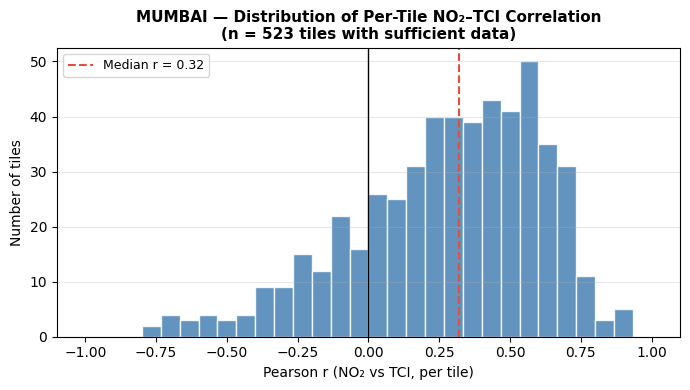

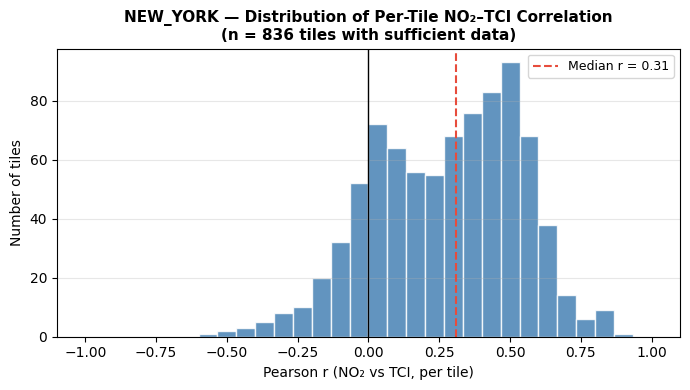

In [ ]:
for city, tile_corr in city_tile_corr.items():
    valid = tile_corr['r'].dropna()
    if valid.empty:
        print(f'{city}: no valid per-tile correlations to plot')
        continue

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(valid, bins=30, range=(-1, 1), color='steelblue', alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', lw=1)
    ax.axvline(valid.median(), color='#e74c3c', lw=1.5, ls='--',
               label=f'Median r = {valid.median():.2f}')
    ax.set_xlabel(f'{TILE_CORR_METHOD.capitalize()} r (NO₂ vs TCI, per tile)', fontsize=10)
    ax.set_ylabel('Number of tiles', fontsize=10)
    ax.set_title(f'{city.upper()} — Distribution of Per-Tile NO₂–TCI Correlation\n'
                 f'(n = {len(valid):,} tiles with sufficient data)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(DATA_ROOT / city / 'grid_panel' / f'{city}_tile_no2_tci_correlation_hist.png',
                dpi=150, bbox_inches='tight')
    plt.show()

### 12.3 Summary table — per-tile correlation by city

A quick numeric companion to the maps: how many tiles have positive vs.
negative vs. insufficient-data correlations, and what's the typical
magnitude, for each city.

In [ ]:
summary_rows = []
for city, tile_corr in city_tile_corr.items():
    valid = tile_corr['r'].dropna()
    summary_rows.append({
        'city': city,
        'n_tiles_total': len(tile_corr),
        'n_tiles_valid': len(valid),
        'pct_valid': 100 * len(valid) / len(tile_corr) if len(tile_corr) else np.nan,
        'pct_positive': 100 * (valid > 0).sum() / len(valid) if len(valid) else np.nan,
        'median_r': valid.median() if len(valid) else np.nan,
        'mean_r': valid.mean() if len(valid) else np.nan,
        'p25_r': valid.quantile(0.25) if len(valid) else np.nan,
        'p75_r': valid.quantile(0.75) if len(valid) else np.nan,
    })

tile_corr_summary = pd.DataFrame(summary_rows)
tile_corr_summary.to_csv(OUTPUT_ROOT / 'tile_no2_tci_correlation_summary_by_city.csv', index=False)
print(tile_corr_summary.round(2).to_string(index=False))

        city  n_tiles_total  n_tiles_valid  pct_valid  pct_positive  median_r  mean_r  p25_r  p75_r
     baghdad           4277           3805      88.96         63.92      0.14    0.14  -0.10   0.40
buenos_aires           4226           3963      93.78         28.29     -0.15   -0.13  -0.32   0.03
       cairo           4025           3407      84.65         83.71      0.38    0.33   0.14   0.59
       dakar            410            393      95.85         37.91     -0.12   -0.09  -0.32   0.11
        lima           1132           1058      93.46          8.70     -0.49   -0.41  -0.59  -0.30
 mexico_city           5580           4953      88.76         77.35      0.33    0.28   0.03   0.55
      mumbai            613            523      85.32         80.31      0.32    0.28   0.07   0.54
    new_york            842            836      99.29         84.09      0.31    0.28   0.07   0.48
